# OpenCV_第1回：画像の読み込み・表示・保存

## 画像の取得

In [1]:
#import sys
#!{sys.executable} -m pip install opencv-python

In [2]:
#!{sys.executable} -m pip install matplotlib

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from zipfile import ZipFile # Python標準ライブラリ, zipファイルを解凍するために使う
from urllib.request import urlretrieve # urllib:標準ライブラリ, urlretrieve:URLからファイルをダウンロードして、指定した名前で保存する関数

from IPython.display import Image # Image:元画像を出力する。matplotlibのimshowは画像処理した結果を出力する。

In [4]:
# 指定したURLからZIPをダウンロードして、解凍する関数
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests....", end="")

    # ダウンロード
    urlretrieve(url, save_path)

    try:
        # 解凍
        with ZipFile(save_path) as z:
            # Zipが置かれているのと同じフォルダに展開
            z.extractall(os.path.split(save_path)[0])
        print("Done")
    
    # エラー処理
    except Exception as e:
        print("\nInvalid file.", e)

In [5]:
URL = r"https://www.dropbox.com/s/qhhlqcica1nvtaw/opencv_bootcamp_assets_NB1.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), f"opencv_bootcamp_assets_NB1.zip")

# 指定パス内にファイルが存在しない場合に以下の関数を実行する
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)  

r"":raw文字列。\nのようなコード上の特殊文字を特殊文字として解釈させないための書き方  

os.getcwd():現在のディレクトリのパスを取得  
os.path.join():パスの連結

In [6]:
# 18x18ピクセル画像の表示
Image(filename="checkerboard_18x18.png")

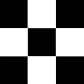

In [7]:
# 84x84ピクセル画像の表示
Image(filename="checkerboard_84x84.jpg")

## 画像の読み込み(OpenCV)

OpenCVは様々な画像(グレースケール、カラー、アルファチャンネル付き画像、など)を読み込める。  

`cv2.imread(filename, flags)`：画像をNumpy配列で出力する  
filename:絶対パスor相対パス  
flags:形式指定。デフォルト値=1(カラー画像)。0_グレースケール。-1_アルファチャンネル(透明度指定)。

In [27]:
# グレースケールで読み込む
cb_img = cv2.imread("checkerboard_18x18.png", 0)

print(cb_img)

[[  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0

In [9]:
# 画像サイズと型

print("Image size (H, W) is:", cb_img.shape)
print("Data type of image is:", cb_img.dtype)

Image size (H, W) is: (18, 18)
Data type of image is: uint8


## 画像の読み込み(Matplotlib)

Numpy配列をimshowに渡すことで、画像を出力できる。  
matplotlibでは2次元配列を渡すと黄色と紫でのみ表示される。

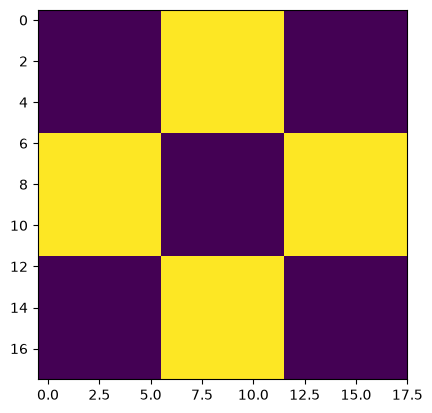

In [28]:
plt.imshow(cb_img)

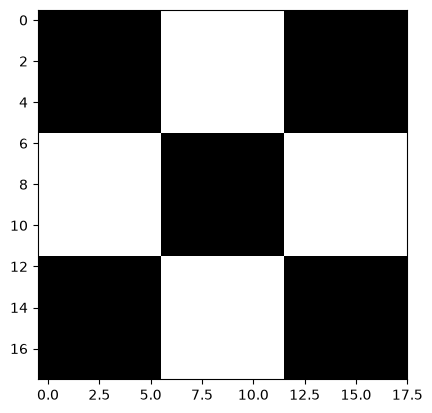

In [29]:
plt.imshow(cb_img, cmap="gray")
# cmapは2次元配列にのみ対応可能

## その他

[[  0   0  15  20   1 134 233 253 253 253 255 229 130   1  29   2   0   0]
 [  0   1   5  18   0 137 232 255 254 247 255 228 129   0  24   2   0   0]
 [  7   5   2  28   2 139 230 254 255 249 255 226 128   0  27   3   2   2]
 [ 25  27  28  38   0 129 236 255 253 249 251 227 129   0  36  27  27  27]
 [  2   0   0   4   2 130 239 254 254 254 255 230 126   0   4   2   0   0]
 [132 129 131 124 121 163 211 226 227 225 226 203 164 125 125 129 131 131]
 [234 227 230 229 232 205 151 115 125 124 117 156 205 232 229 225 228 228]
 [254 255 255 251 255 222 102   1   0   0   0 120 225 255 254 255 255 255]
 [254 255 254 255 253 225 104   0  50  46   0 120 233 254 247 253 251 253]
 [252 250 250 253 254 223 105   2  45  50   0 127 223 255 251 255 251 253]
 [254 255 255 252 255 226 104   0   1   1   0 120 229 255 255 254 255 255]
 [233 235 231 233 234 207 142 106 108 102 108 146 207 235 237 232 231 231]
 [132 132 131 132 130 175 207 223 224 224 224 210 165 134 130 136 134 134]
 [  1   1   3   0   0 129

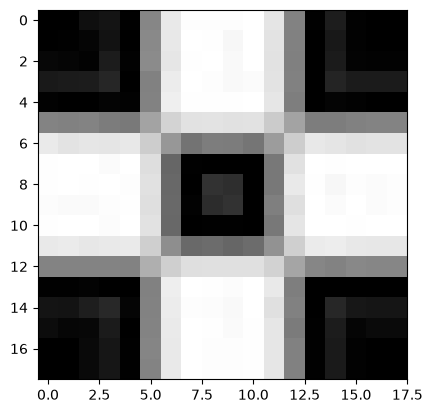

In [12]:
# Read image as gray scale.
cb_img_fuzzy = cv2.imread("checkerboard_fuzzy_18x18.jpg", 0)

# print image
print(cb_img_fuzzy)

# Display image.
plt.imshow(cb_img_fuzzy, cmap="gray")

## カラー画像の取り扱い

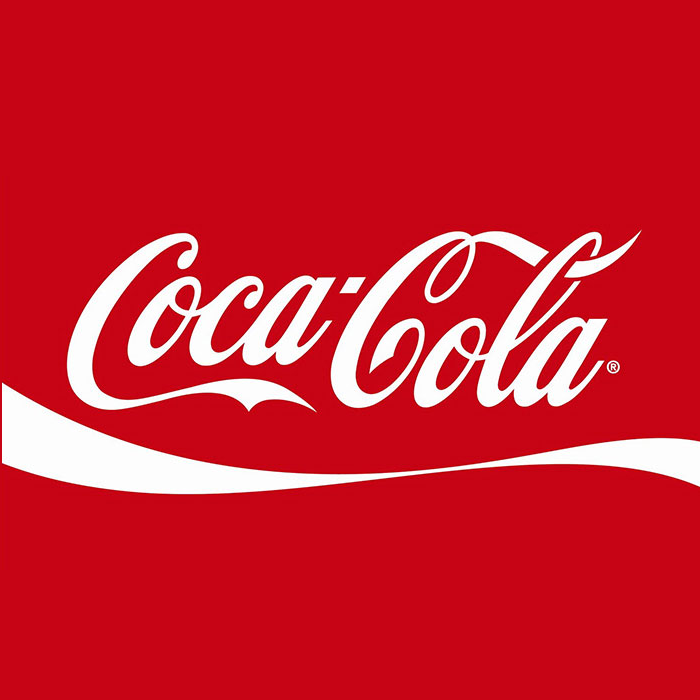

In [13]:
# Read and display Coca-Cola logo.
Image("coca-cola-logo.png")

In [14]:
# カラー画像のサイズと型
coke_img = cv2.imread("coca-cola-logo.png", 1)

print("Image size (H, W, C) is:", coke_img.shape)
print("Data type of image is:", coke_img.dtype)

Image size (H, W, C) is: (700, 700, 3)
Data type of image is: uint8


グレースケールとは異なり、RGBの3チャネル画像であることが分かる

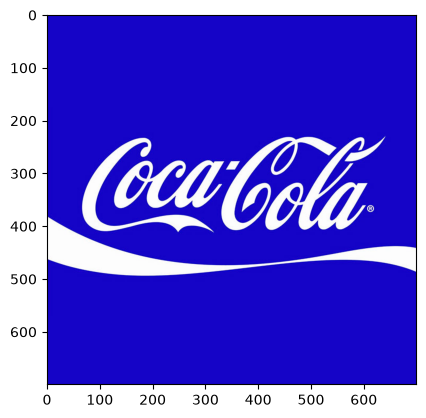

In [15]:
plt.imshow(coke_img)

元画像:R255,G0,B0をcv2.imreadに渡すことでB0,G0,R255の順に変数に格納する。そのままmatplotlibに渡すとmatplotlibはRGB順で読み取るので、B:255と解釈してしまう！

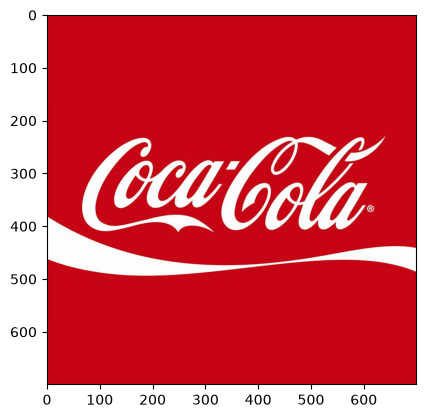

In [16]:
# Numpyのスライスで[H, W, C(逆順)]にすることで解決する
coke_img_channels_reversed = coke_img[:, :, ::-1]
plt.imshow(coke_img_channels_reversed)

OpenCVではチャネルの順序規則に注意する必要がある

## カラーチャネルの分割と結合

`cv2.split()`
多チャンネルの配列を複数の単一チャンネル配列に分割する  
`cv2.merge()`
複数の配列を結合して、1つの多チャンネル配列を作る。入力する行列は全て同じサイズでなければならない。  

Text(0.5, 1.0, 'Merged Output')

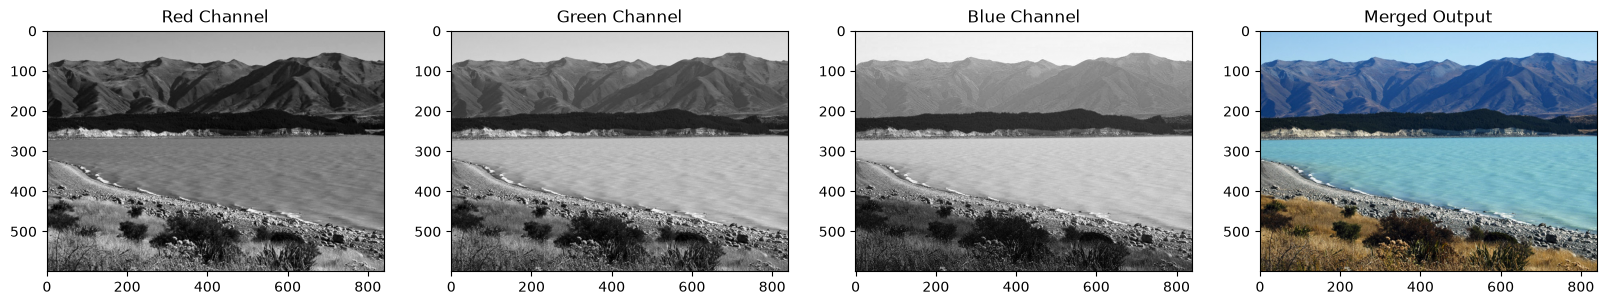

In [17]:
# カラーチャネルの分割
img_NZ_bgr = cv2.imread("New_Zealand_Lake.jpg", cv2.IMREAD_COLOR)
b, g, r = cv2.split(img_NZ_bgr)

# Show the channels
plt.figure(figsize=[20, 5]) # キャンバス準備

plt.subplot(141);plt.imshow(r, cmap="gray");plt.title("Red Channel")
plt.subplot(142);plt.imshow(g, cmap="gray");plt.title("Green Channel")
plt.subplot(143);plt.imshow(b, cmap="gray");plt.title("Blue Channel")

# 再結合して表示
imgMerged = cv2.merge((b, g, r))

plt.subplot(144)
plt.imshow(imgMerged[:, :, ::-1])
plt.title("Merged Output")

cv2.IMREAD_COLOR:flags=1と同じ意味。  
cv2.split():3チャネル(BGR)を3つ(B,G,R)に分割する。  

subplot(141):(行,列,n番目)を3桁の数字で表現

## 異なる色空間への変換

`cv2.cvtColor()`  
ある色空間から別の色空間へ変換する。RGB色空間との相互変換を行う場合は、チャンネルの順序（RGBかBGRか）を明示的に指定する必要がある。  

cv2.cvtColor( src, code )  
`src`:入力画像。  
`code`:色空間の変換コード

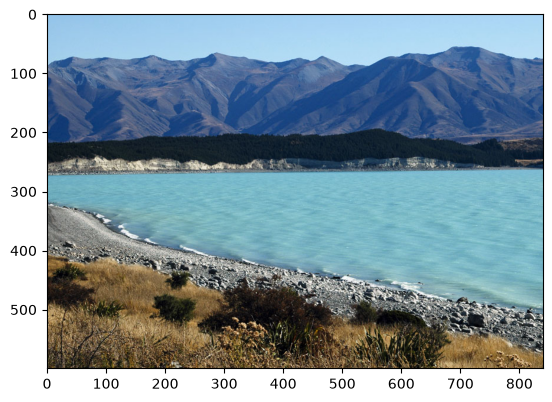

In [18]:
# BGRからRGBへの変換
# OpenCV stores color channels in a differnet order than most other applications (BGR vs RGB).
img_NZ_rgb = cv2.cvtColor(img_NZ_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_NZ_rgb)

`COLOR_BGR2GRAY`：グレースケール化  
`COLOR_BGR2HSV`：色相(H)、彩度(S)、明度(V)の3要素に分解して出力する

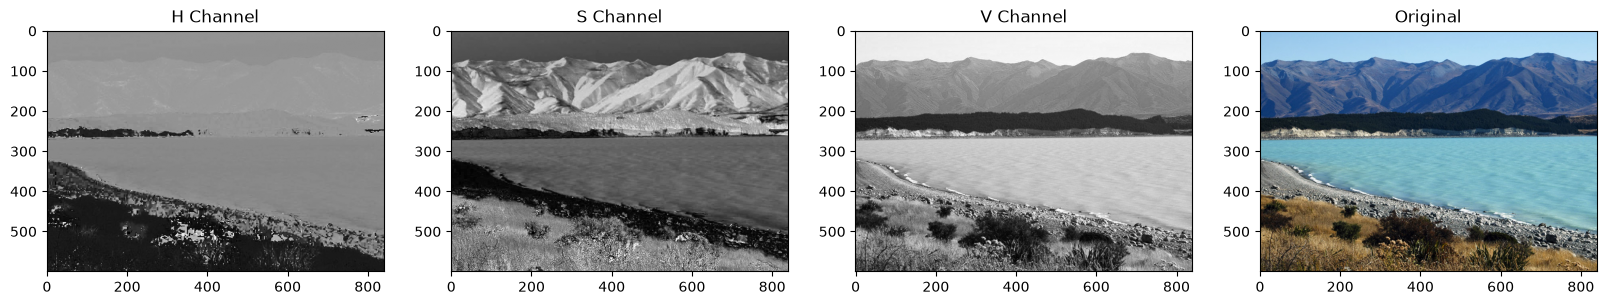

In [19]:
# HSV空間への変換
img_hsv = cv2.cvtColor(img_NZ_bgr, cv2.COLOR_BGR2HSV)

# Split the image into the B,G,R components
h,s,v = cv2.split(img_hsv)

# Show the channels
plt.figure(figsize=[20,5])
plt.subplot(141);plt.imshow(h, cmap="gray");plt.title("H Channel");
plt.subplot(142);plt.imshow(s, cmap="gray");plt.title("S Channel");
plt.subplot(143);plt.imshow(v, cmap="gray");plt.title("V Channel");
plt.subplot(144);plt.imshow(img_NZ_rgb);   plt.title("Original");

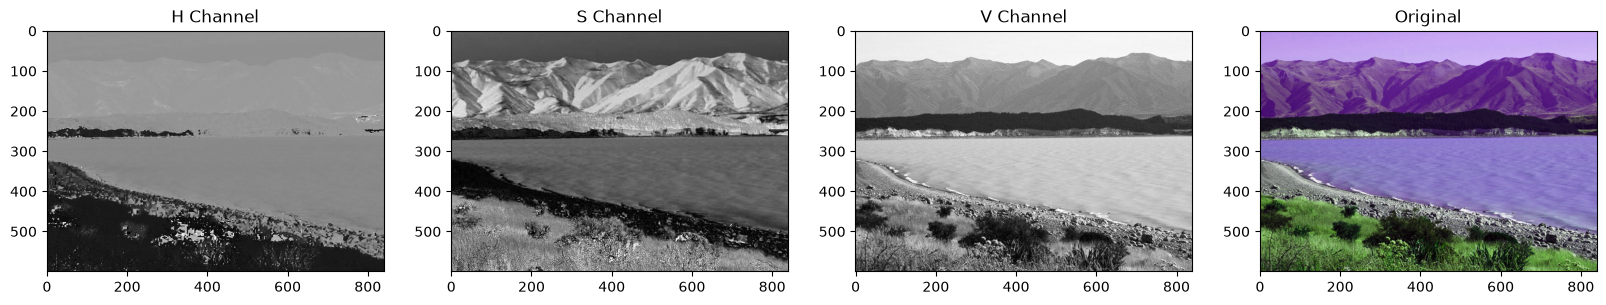

In [33]:
# 色相を変更して画像全体の色味を変えて出力
h_new = h + 30
img_NZ_merged = cv2.merge((h_new, s, v))
img_NZ_rgb = cv2.cvtColor(img_NZ_merged, cv2.COLOR_HSV2RGB)

# Show the channels
plt.figure(figsize=[20,5])
plt.subplot(141);plt.imshow(h, cmap="gray");plt.title("H Channel");
plt.subplot(142);plt.imshow(s, cmap="gray");plt.title("S Channel");
plt.subplot(143);plt.imshow(v, cmap="gray");plt.title("V Channel");
plt.subplot(144);plt.imshow(img_NZ_rgb);   plt.title("Original");

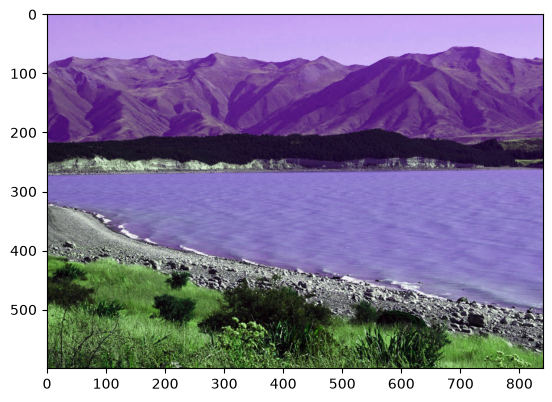

In [34]:
plt.imshow(img_NZ_rgb)

## 画像の保存

`cv2.imwrite(filename, img[, params])`：指定したファイルに画像を保存する  
filename:絶対パス、相対パス  
img:保存する画像  
params:品質や圧縮率の指定(任意)

・保存時はBGR順である必要がある。
・拡張子でフォーマットが決まる。処理途中の画像を保存する場合は`PNG`を選択する。JPEGは保存するたびに画質が落ちる。  
・保存に失敗してもエラーが出ないので、戻り値を確認する習慣をつける。

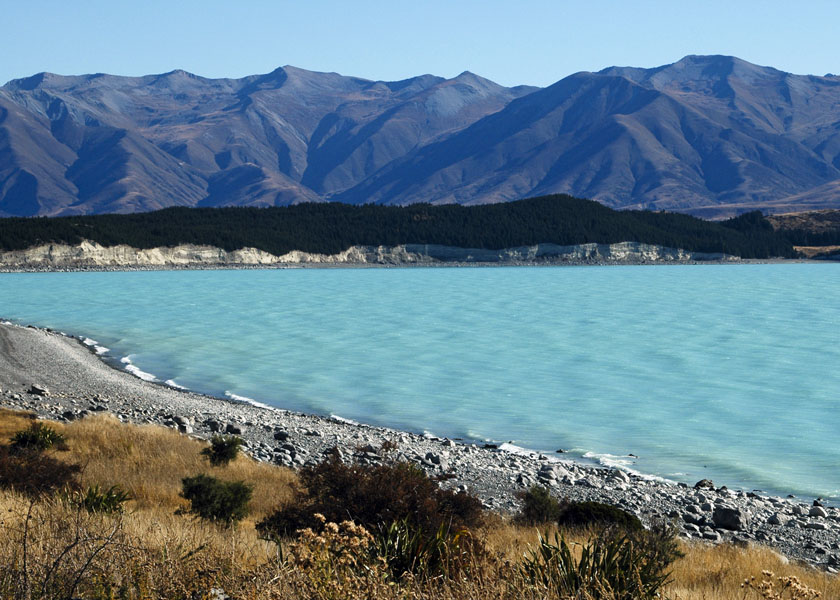

In [21]:
# save the image
ok = cv2.imwrite("New_Zealand_Lake_SAVED.png", img_NZ_bgr)
if not ok:
    raise IOError("保存に失敗しました")
Image(filename='New_Zealand_Lake_SAVED.png') 

In [22]:
# read the image as Color
img_NZ_bgr = cv2.imread("New_Zealand_Lake_SAVED.png", cv2.IMREAD_COLOR)
print("img_NZ_bgr shape (H, W, C) is:", img_NZ_bgr.shape)

# read the image as Grayscaled
img_NZ_gry = cv2.imread("New_Zealand_Lake_SAVED.png", cv2.IMREAD_GRAYSCALE)
print("img_NZ_gry shape (H, W) is:", img_NZ_gry.shape)

img_NZ_bgr shape (H, W, C) is: (600, 840, 3)
img_NZ_gry shape (H, W) is: (600, 840)


In [23]:
import cv2
print(cv2.__version__)

5.0.0
